In [1]:
from utils.text_utils import *
from utils import data_analysis_utils as data

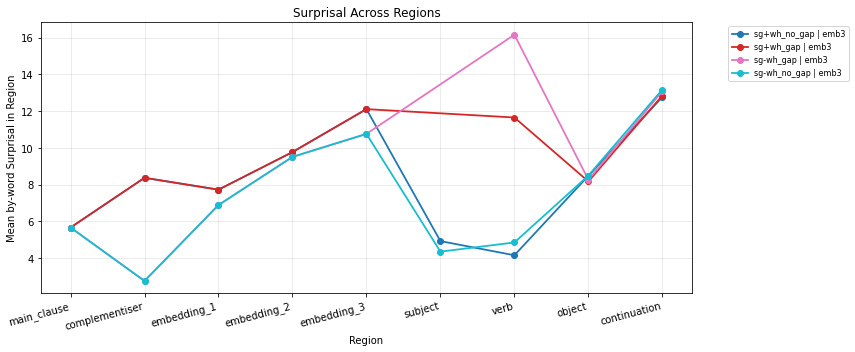

In [2]:
configs = [
    {'sentence_group': 3, 'condition': '+wh_no_gap', 'levels_of_embedding': 3},
    {'sentence_group': 3, 'condition': '+wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 3, 'condition': '-wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 3, 'condition': '-wh_no_gap', 'levels_of_embedding': 3},
]

data.plot_surprisal_lines('../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv', configs)

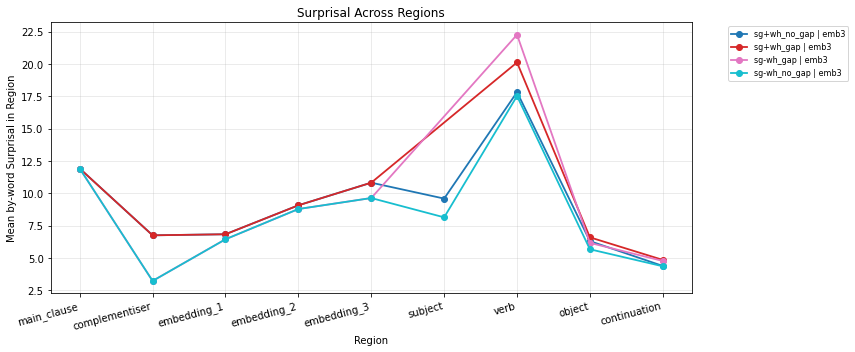

In [3]:
configs = [
    {'sentence_group': 1, 'condition': '+wh_no_gap', 'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '+wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '-wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '-wh_no_gap', 'levels_of_embedding': 3},
]

data.plot_surprisal_lines('../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv', configs)

### note on comparing across gap/no gap conditions
seems like broadly speaking object surprisal is higher than continuation surprisal: unclear why but would explain current results, might be necessary to rely on global metrics or introduce some kind of norming by word frequency (dividing by context-less surprisal)?

this also applies to subject surprisal vs verb surprisal: interesting?

**Wilcox 2022, wh-effect**

| | +wh | -wh |
|---|---|---|
| **+gap** | I know what the lion devoured _ at sunrise. | *I know that the lion devoured _ at sunrise. |
| **-gap** | *I know what the lion devoured a gazelle at sunrise. | I know that the lion devoured a gazelle at sunrise. |


---


**filler_offloading**

| | +gap | -gap |
|---|---|---|
| **+wh** | I know what the lion devoured _ at sunrise. | *I know what the lion devoured a gazelle at sunrise. |
| **-wh** | *I know that the lion devoured _ at sunrise. | I know that the lion devoured a gazelle at sunrise. |


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=-6.051, sd=3.621, n=3
    embedding 1: mean=-4.249, sd=3.394, n=3
    embedding 2: mean=-4.405, sd=1.914, n=3
    embedding 3: mean=-2.974, sd=1.331, n=3

  -gap:
    embedding 0: mean=1.117, sd=0.661, n=3
    embedding 1: mean=2.278, sd=0.232, n=3
    embedding 2: mean=3.154, sd=1.810, n=3
    embedding 3: mean=1.685, sd=1.479, n=3


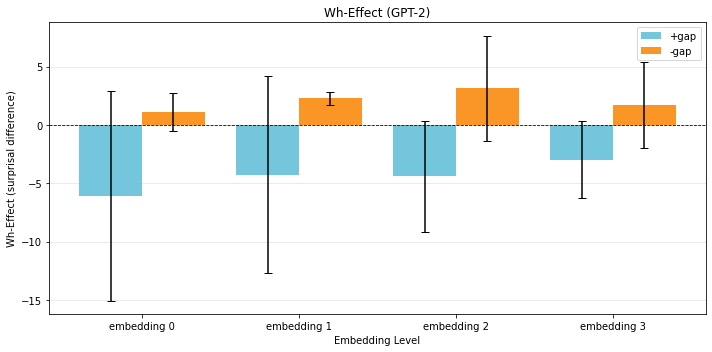


=== STANDARD DEVIATIONS (Local Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=7.304, sd=5.029, n=3
    embedding 1: mean=8.753, sd=4.882, n=3
    embedding 2: mean=8.544, sd=4.448, n=3
    embedding 3: mean=9.814, sd=3.637, n=3

  -wh:
    embedding 0: mean=14.472, sd=1.203, n=3
    embedding 1: mean=15.280, sd=2.962, n=3
    embedding 2: mean=16.103, sd=4.401, n=3
    embedding 3: mean=14.473, sd=3.178, n=3


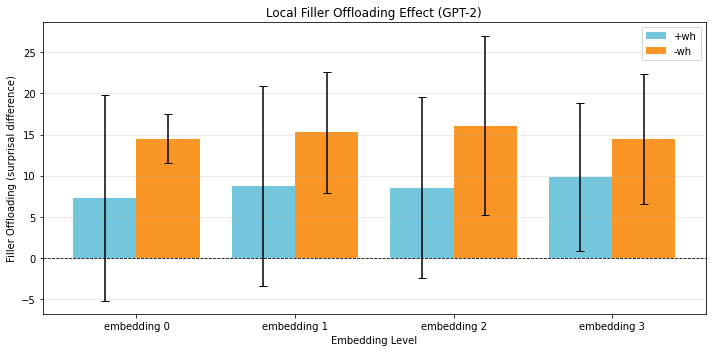

In [4]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="local",
    gap_type="subject"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Local Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
    surprisal_type="local",
    gap_type="subject"
)


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=-1.512, sd=1.528, n=3
    embedding 1: mean=-1.050, sd=1.079, n=3
    embedding 2: mean=-0.898, sd=0.744, n=3
    embedding 3: mean=-0.627, sd=0.523, n=3

  -gap:
    embedding 0: mean=0.275, sd=0.528, n=3
    embedding 1: mean=0.467, sd=0.312, n=3
    embedding 2: mean=0.674, sd=0.504, n=3
    embedding 3: mean=0.165, sd=0.392, n=3


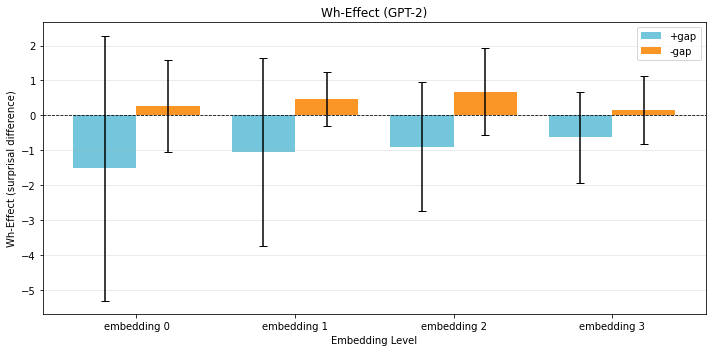


=== STANDARD DEVIATIONS (Local Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=0.366, sd=0.720, n=3
    embedding 1: mean=0.739, sd=1.001, n=3
    embedding 2: mean=0.906, sd=1.238, n=3
    embedding 3: mean=1.421, sd=1.287, n=3

  -wh:
    embedding 0: mean=2.153, sd=1.613, n=3
    embedding 1: mean=2.256, sd=1.775, n=3
    embedding 2: mean=2.479, sd=1.620, n=3
    embedding 3: mean=2.213, sd=1.642, n=3


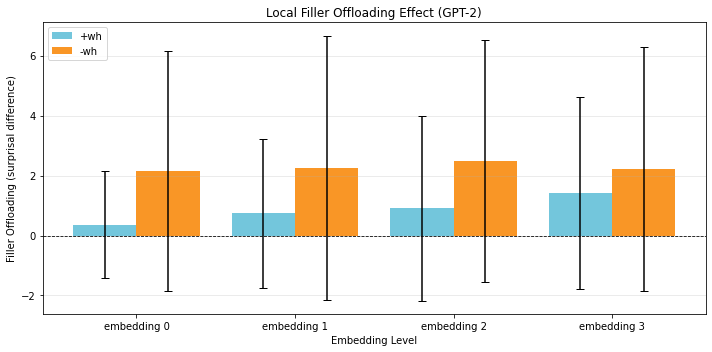

In [5]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="semi_local",
    gap_type="subject"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Local Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
     surprisal_type="semi_local",
    gap_type="subject"
)


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=-0.127, sd=0.813, n=3
    embedding 1: mean=0.248, sd=0.314, n=3
    embedding 2: mean=0.342, sd=0.171, n=3
    embedding 3: mean=0.566, sd=0.142, n=3

  -gap:
    embedding 0: mean=0.769, sd=0.435, n=3
    embedding 1: mean=0.799, sd=0.157, n=3
    embedding 2: mean=0.836, sd=0.094, n=3
    embedding 3: mean=0.707, sd=0.038, n=3


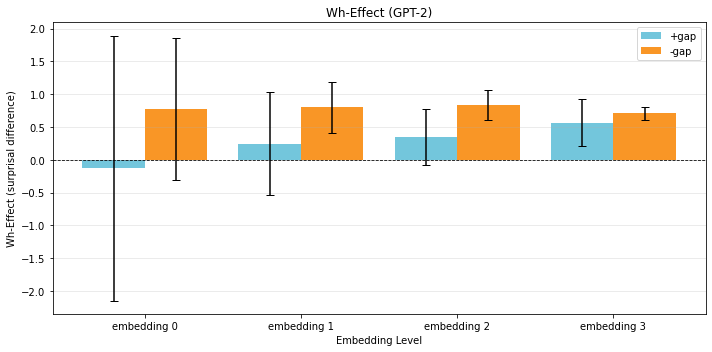


=== STANDARD DEVIATIONS (Local Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=0.283, sd=0.364, n=3
    embedding 1: mean=0.312, sd=0.314, n=3
    embedding 2: mean=0.339, sd=0.367, n=3
    embedding 3: mean=0.546, sd=0.434, n=3

  -wh:
    embedding 0: mean=1.179, sd=0.631, n=3
    embedding 1: mean=0.863, sd=0.513, n=3
    embedding 2: mean=0.833, sd=0.404, n=3
    embedding 3: mean=0.686, sd=0.470, n=3


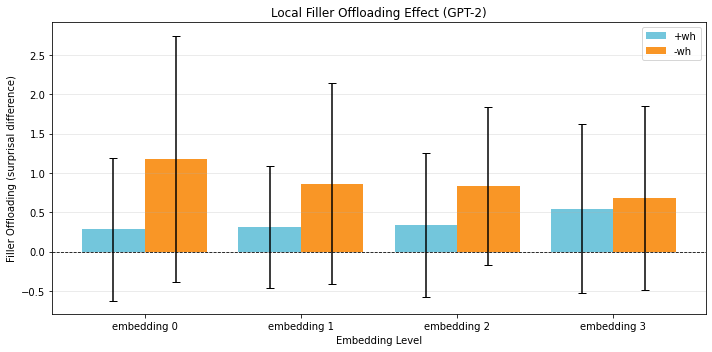

In [6]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="global",
    gap_type="subject"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Local Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
     surprisal_type="global",
    gap_type="subject"
)

# Metrics - local surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

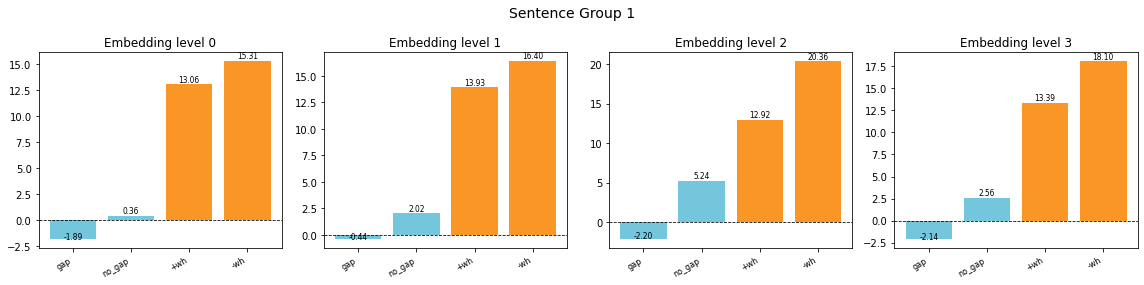

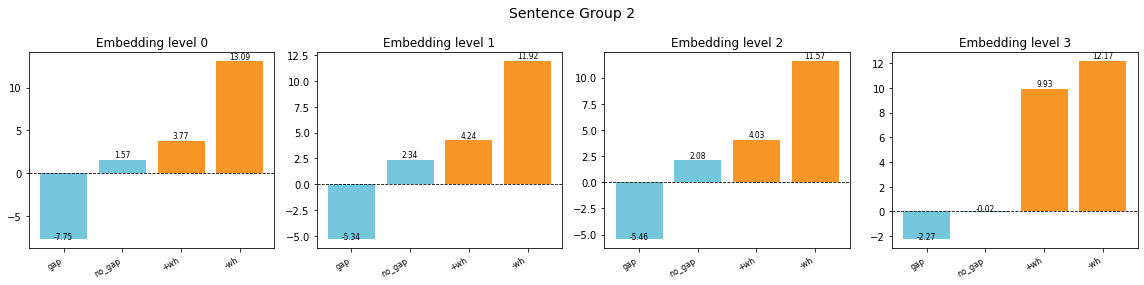

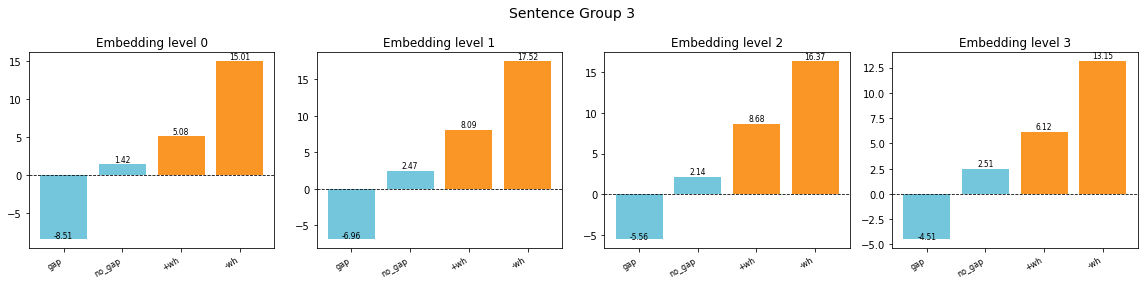

In [9]:
gpt2_df = pd.read_csv("../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(gpt2_df, surprisal_type='local', gap_type="subject")

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

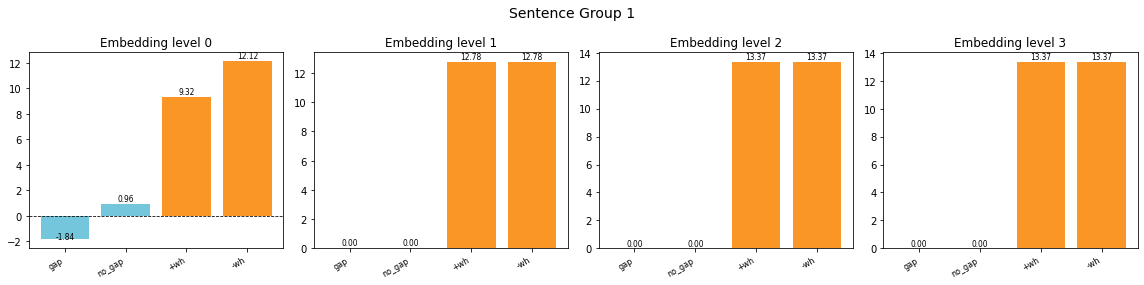

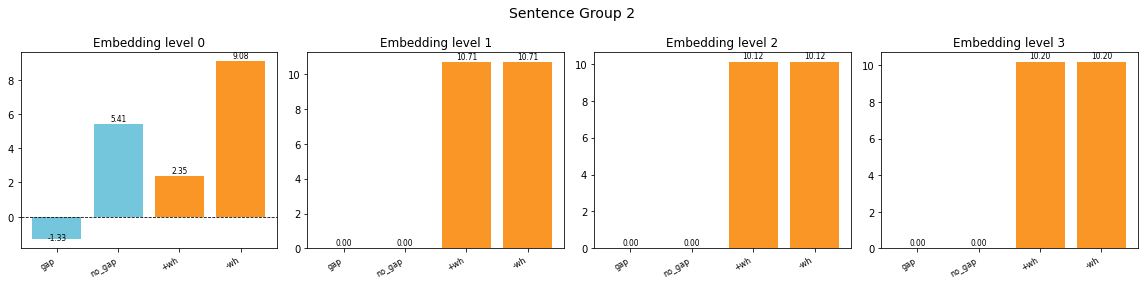

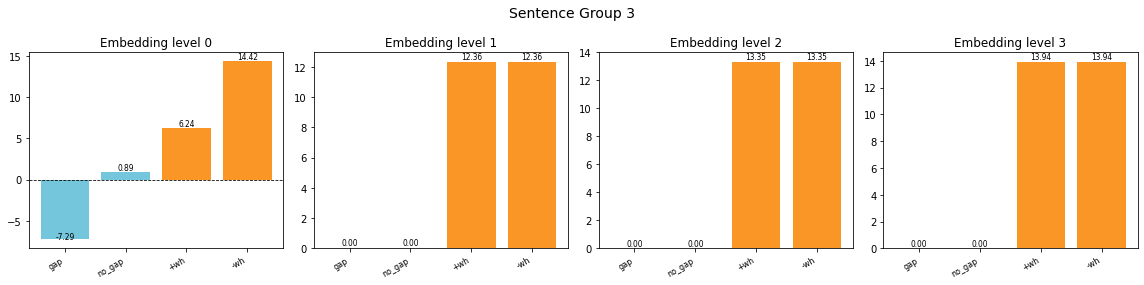

In [10]:
ngram_df = pd.read_csv("../data/model_outputs/ngram_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(ngram_df, surprisal_type='local', gap_type="subject")

## grnn metrics

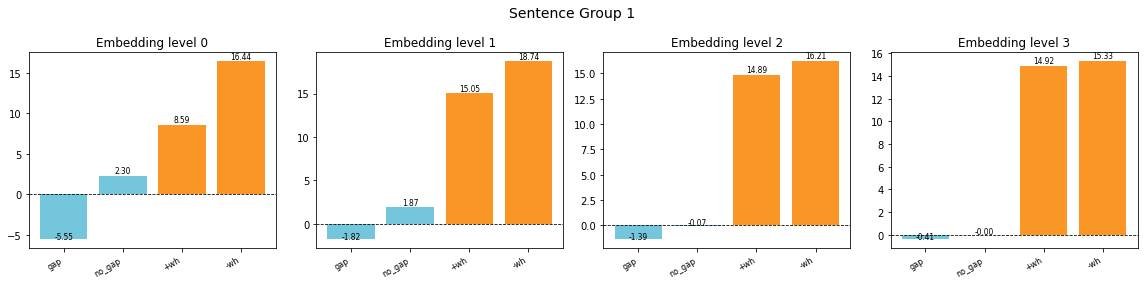

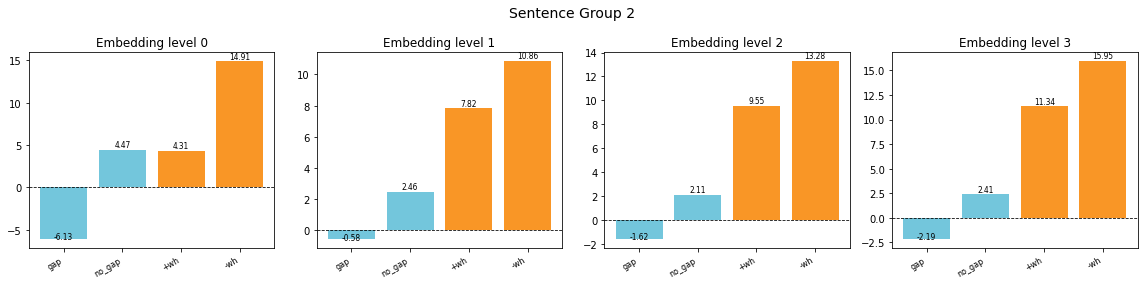

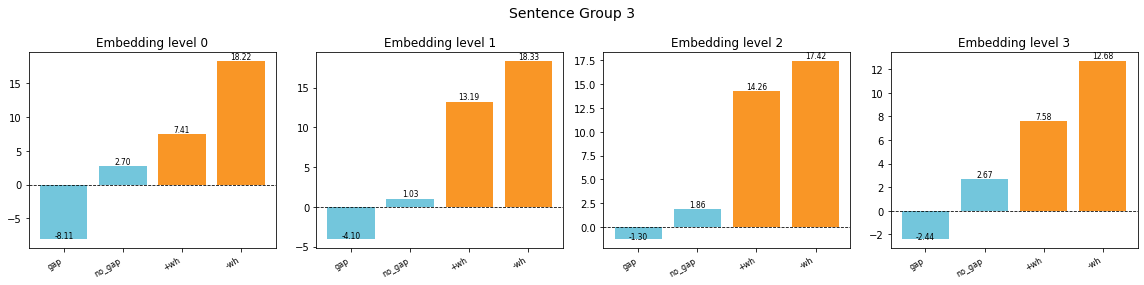

In [11]:
grnn_df = pd.read_csv("../data/model_outputs/grnn_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(grnn_df, surprisal_type='local', gap_type="subject")

/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2128: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2129: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2128: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2129: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc



=== STANDARD DEVIATIONS (Wh-effect by model and embedding level) ===

  [GPT-2]
  gap:
    embedding 0: mean=-6.051, sd=3.621, n=3
    embedding 1: mean=-4.249, sd=3.394, n=3
    embedding 2: mean=-4.405, sd=1.914, n=3
    embedding 3: mean=-2.974, sd=1.331, n=3
  no_gap:
    embedding 0: mean=1.117, sd=0.661, n=3
    embedding 1: mean=2.278, sd=0.232, n=3
    embedding 2: mean=3.154, sd=1.810, n=3
    embedding 3: mean=1.685, sd=1.479, n=3

  [GRNN]
  gap:
    embedding 0: mean=-6.596, sd=1.341, n=3
    embedding 1: mean=-2.168, sd=1.785, n=3
    embedding 2: mean=-1.434, sd=0.168, n=3
    embedding 3: mean=-1.682, sd=1.106, n=3
  no_gap:
    embedding 0: mean=3.157, sd=1.151, n=3
    embedding 1: mean=1.787, sd=0.714, n=3
    embedding 2: mean=1.304, sd=1.192, n=3
    embedding 3: mean=1.691, sd=1.472, n=3

  [ngram]
  gap:
    embedding 0: mean=-3.487, sd=3.302, n=3
    embedding 1: mean=0.000, sd=0.000, n=3
    embedding 2: mean=0.000, sd=0.000, n=3
    embedding 3: mean=0.000, sd

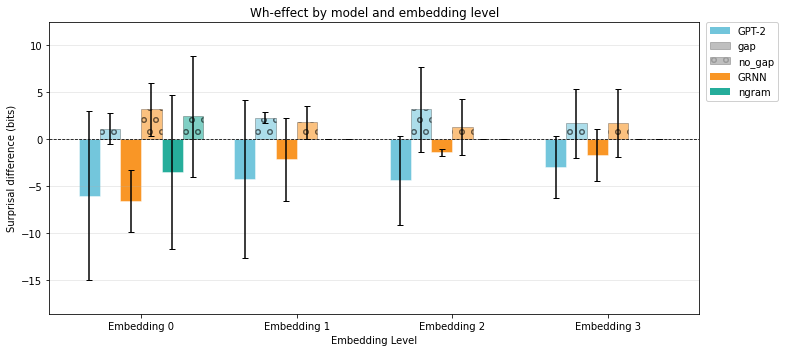

In [13]:
model_dfs = {
    "GPT-2": gpt2_df,
    "GRNN":  grnn_df,
    "ngram": ngram_df,
}

data.plot_effect_bar_chart_multi_model(
    model_dfs     = model_dfs,
    effect_fn     = data.get_wh_effect,
    conditions    = ["gap", "no_gap"],
    title         = "Wh-effect by model and embedding level",
    ylabel        = "Surprisal difference (bits)",
    surprisal_type= "local",
    gap_type      = "subject",
    condition_labels = ["gap", "no_gap"],
    save_path = "../data/images/wh_effect_main_subject.png"
)


=== STANDARD DEVIATIONS (Filler-offloading effect by model and embedding level) ===

  [GPT-2]
  +wh:
    embedding 0: mean=7.304, sd=5.029, n=3
    embedding 1: mean=8.753, sd=4.882, n=3
    embedding 2: mean=8.544, sd=4.448, n=3
    embedding 3: mean=9.814, sd=3.637, n=3
  -wh_gap:
    embedding 0: mean=14.472, sd=1.203, n=3
    embedding 1: mean=15.280, sd=2.962, n=3
    embedding 2: mean=16.103, sd=4.401, n=3
    embedding 3: mean=14.473, sd=3.178, n=3

  [GRNN]
  +wh:
    embedding 0: mean=6.771, sd=2.208, n=3
    embedding 1: mean=12.021, sd=3.754, n=3
    embedding 2: mean=12.900, sd=2.918, n=3
    embedding 3: mean=11.280, sd=3.671, n=3
  -wh_gap:
    embedding 0: mean=16.524, sd=1.657, n=3
    embedding 1: mean=15.976, sd=4.438, n=3
    embedding 2: mean=15.638, sd=2.126, n=3
    embedding 3: mean=14.652, sd=1.735, n=3

  [ngram]
  +wh:
    embedding 0: mean=5.968, sd=3.493, n=3
    embedding 1: mean=11.951, sd=1.092, n=3
    embedding 2: mean=12.280, sd=1.866, n=3
    embedd

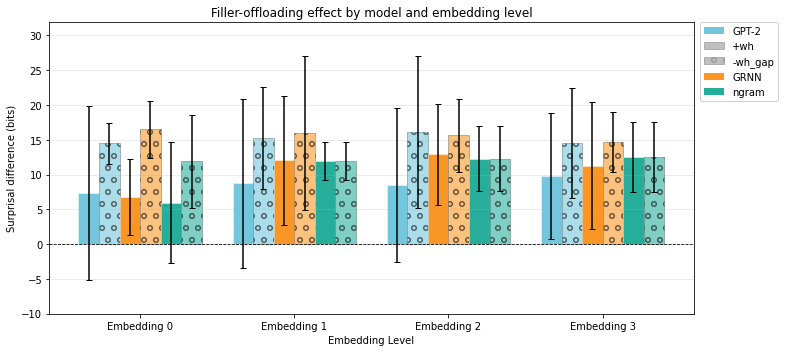

In [14]:
model_dfs = {
    "GPT-2": gpt2_df,
    "GRNN":  grnn_df,
    "ngram": ngram_df,
}

data.plot_effect_bar_chart_multi_model(
    model_dfs     = model_dfs,
    effect_fn     = data.get_filler_offloading_effect,
    conditions    = ["+wh", "-wh"],
    title         = "Filler-offloading effect by model and embedding level",
    ylabel        = "Surprisal difference (bits)",
    surprisal_type= "local",
    gap_type      = "subject",
    condition_labels = ["+wh", "-wh_gap"],
    save_path = "../data/images/subject_fo_effect_main_subject.png"
)

# Metrics - semi-local surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

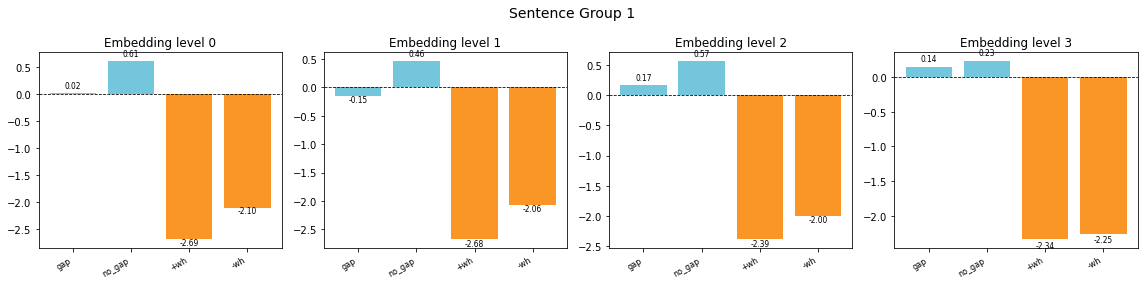

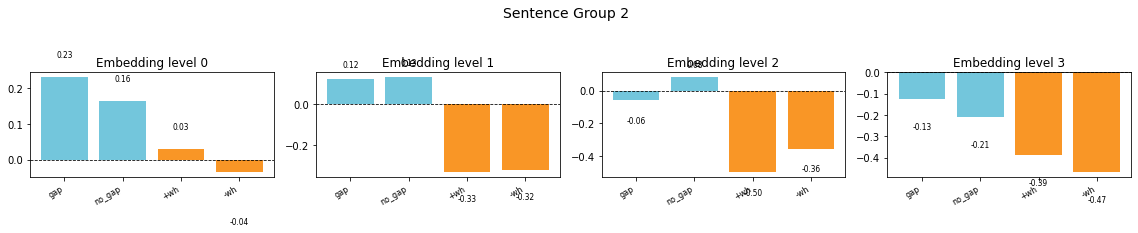

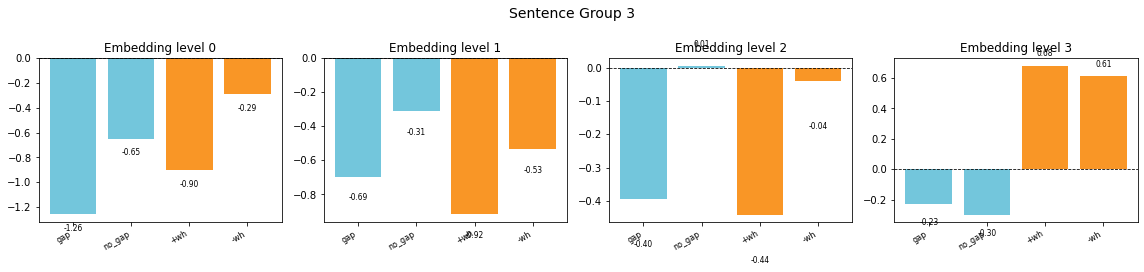

In [18]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local', gap_type="subject")

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

/home/marrsia/UCL_dissertation/ucl-fgd/utils/data_analysis_utils.py:355: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


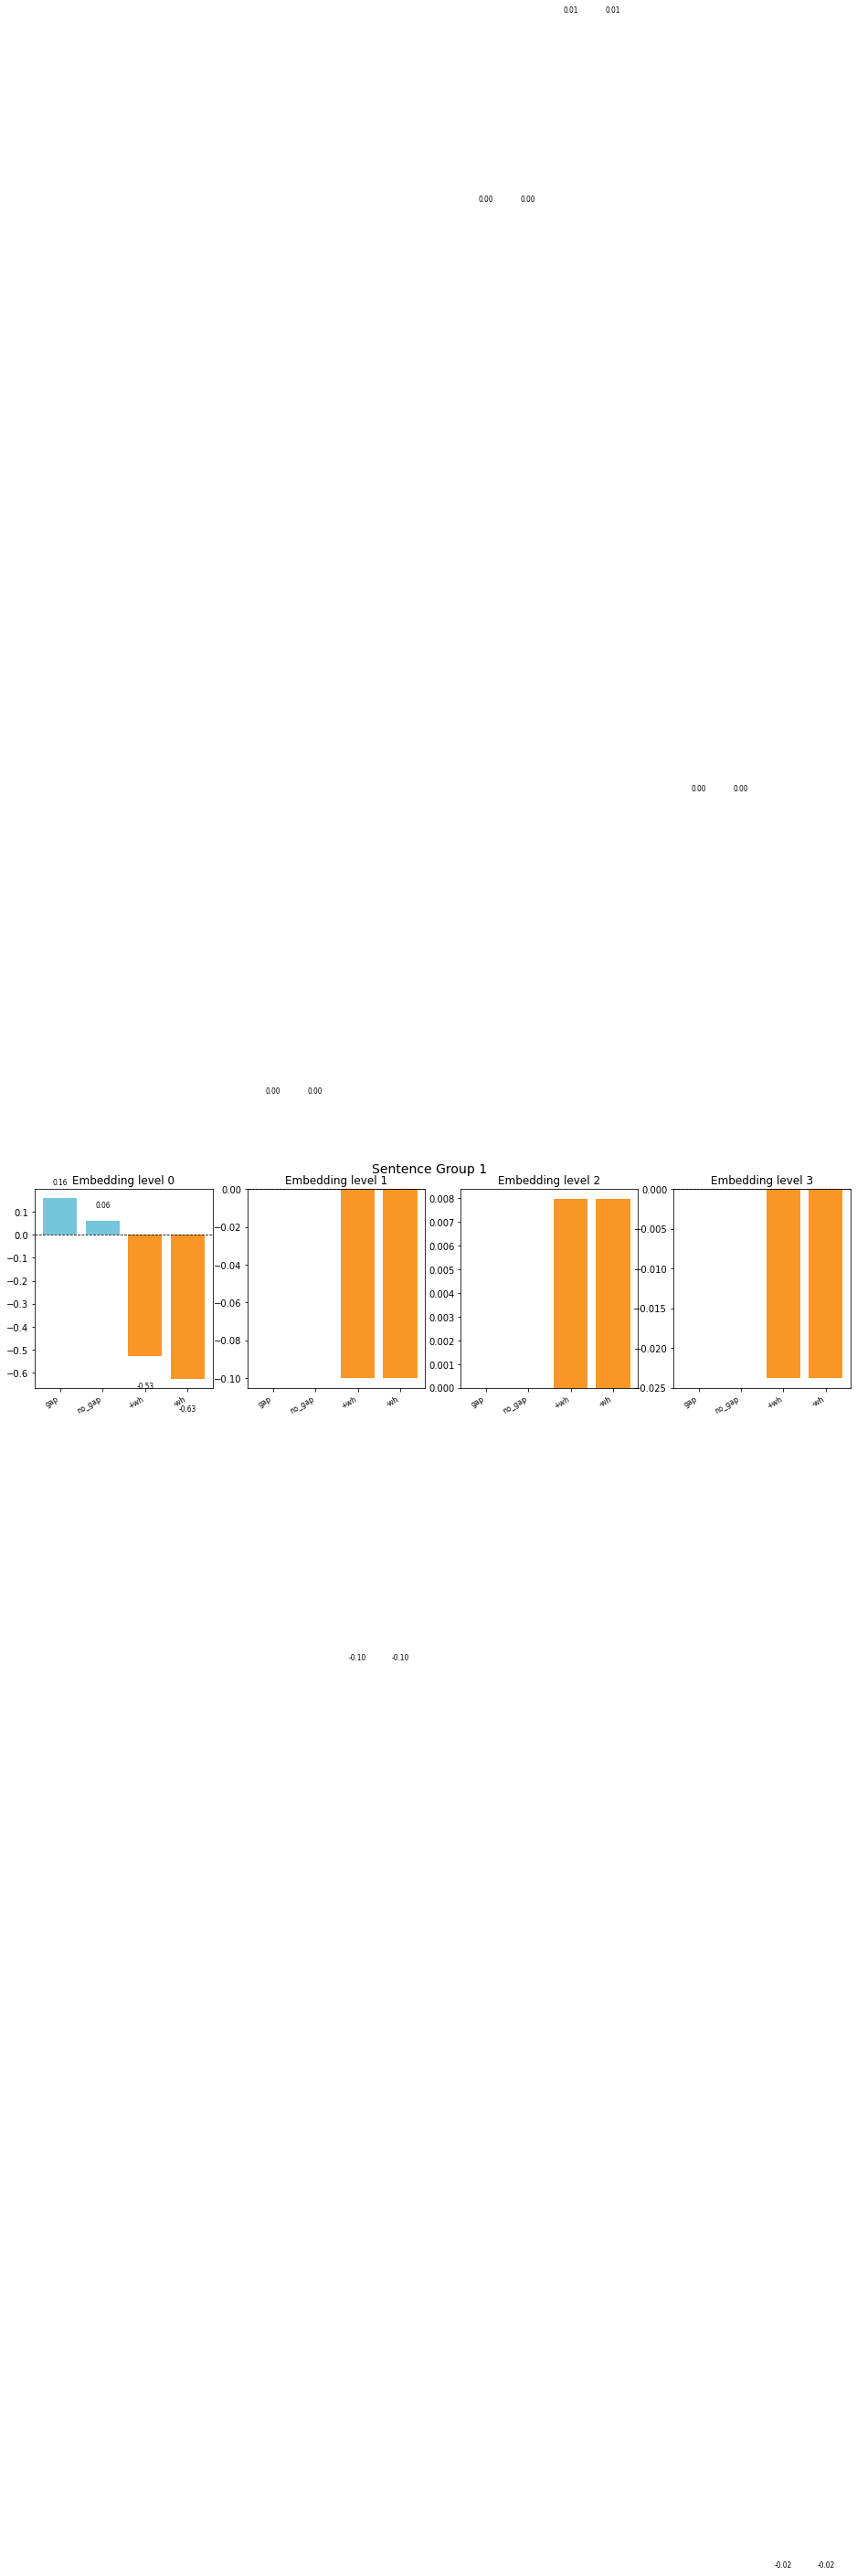

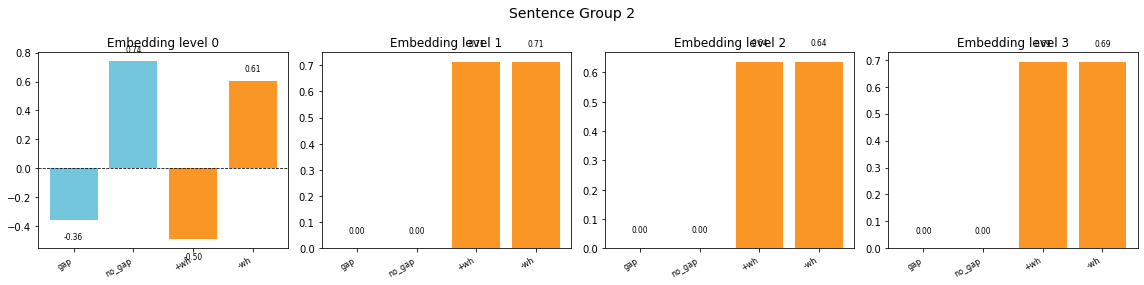

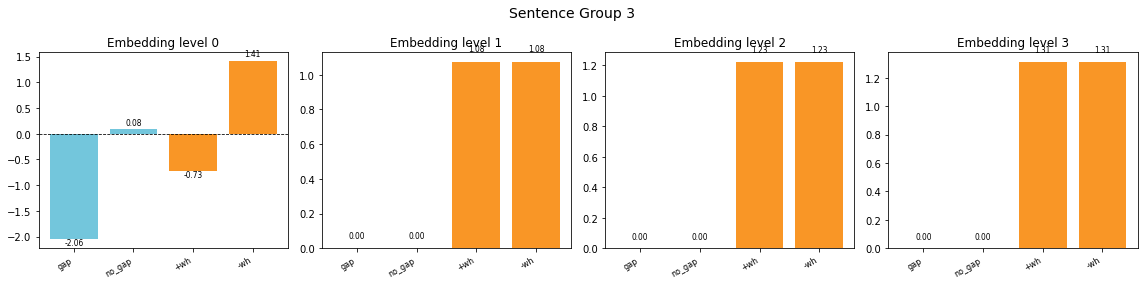

In [20]:
df = pd.read_csv("../data/model_outputs/ngram_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local', gap_type="subject")

## grnn metrics

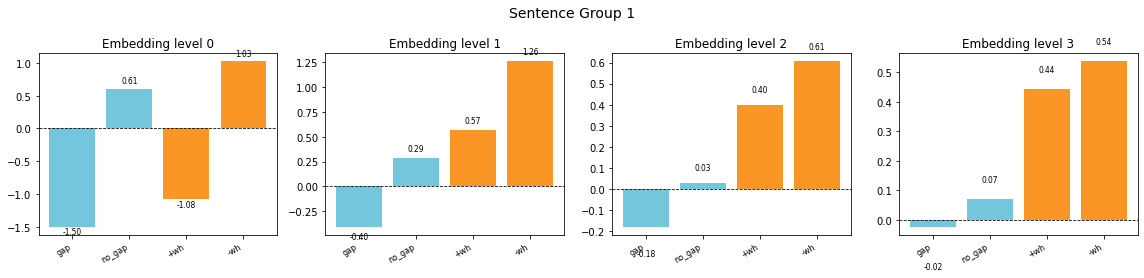

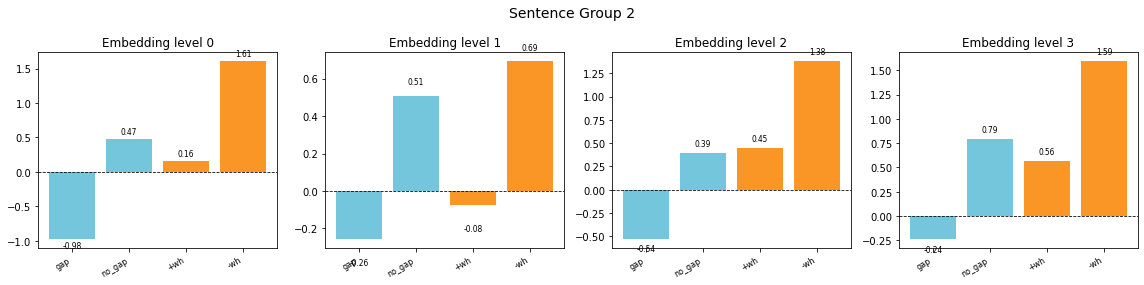

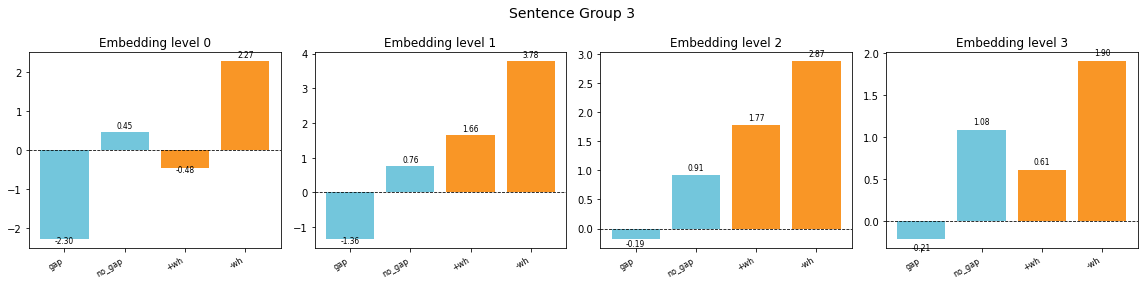

In [21]:
df = pd.read_csv("../data/model_outputs/grnn_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local', gap_type="subject")

# Metrics - global surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

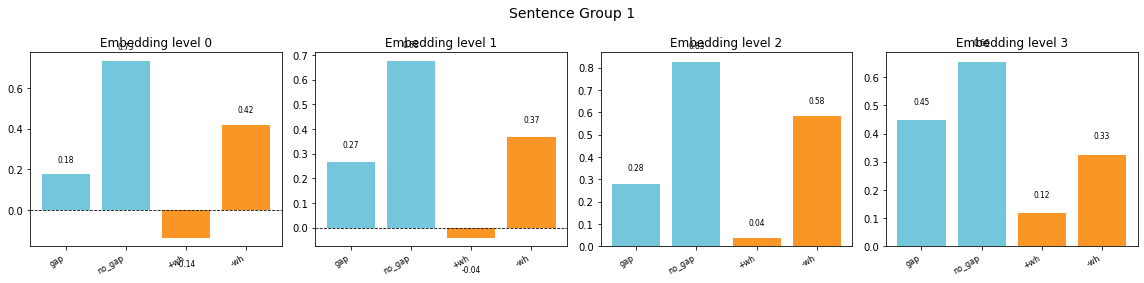

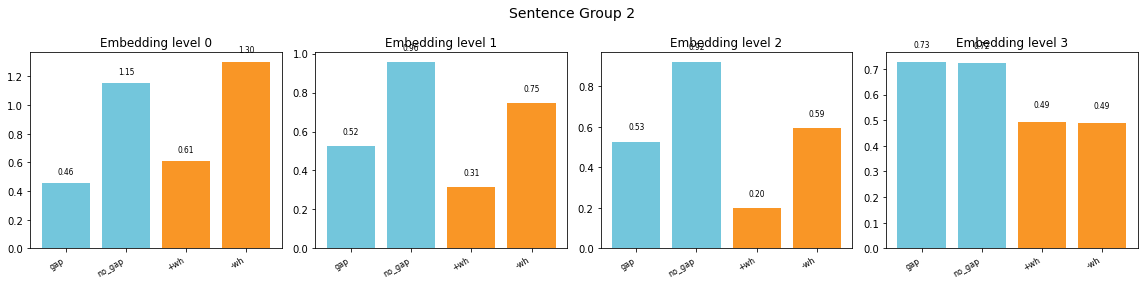

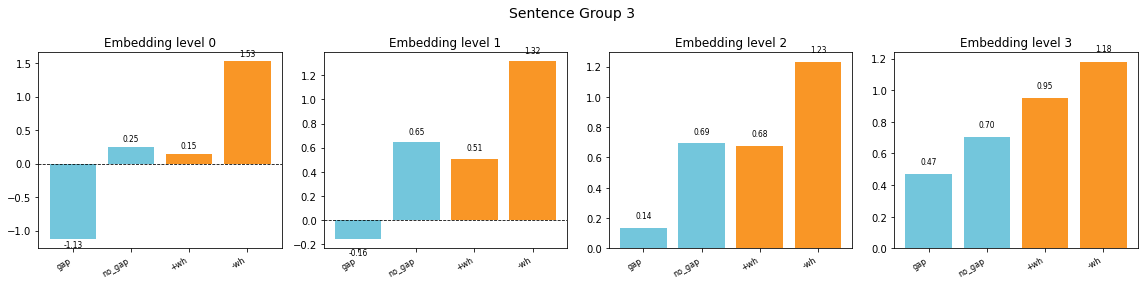

In [22]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global', gap_type='subject')

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

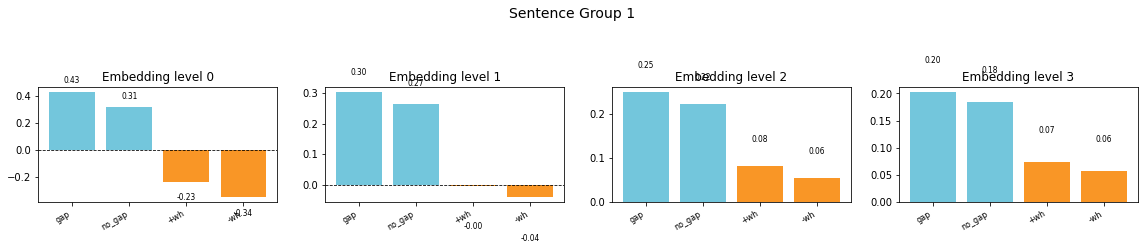

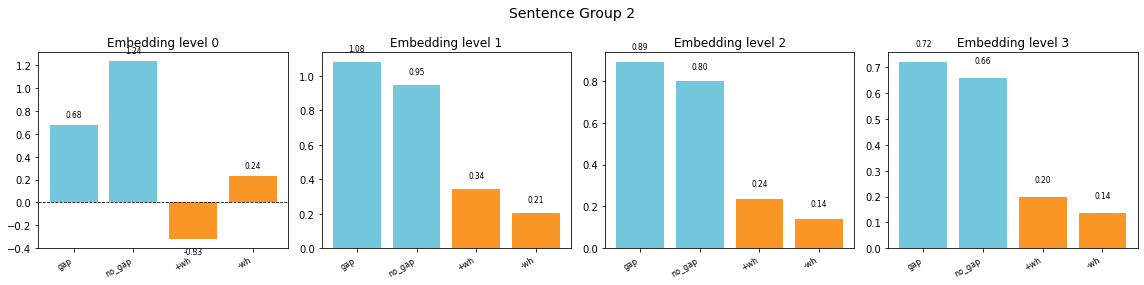

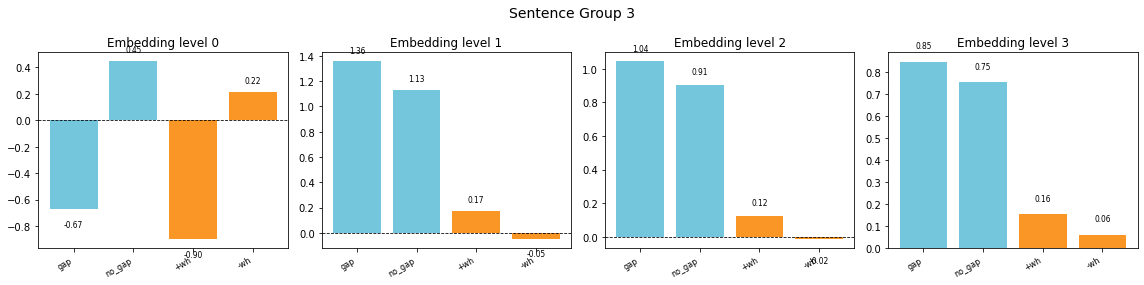

In [23]:
df = pd.read_csv("../data/model_outputs/ngram_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global', gap_type='subject')

## grnn metrics

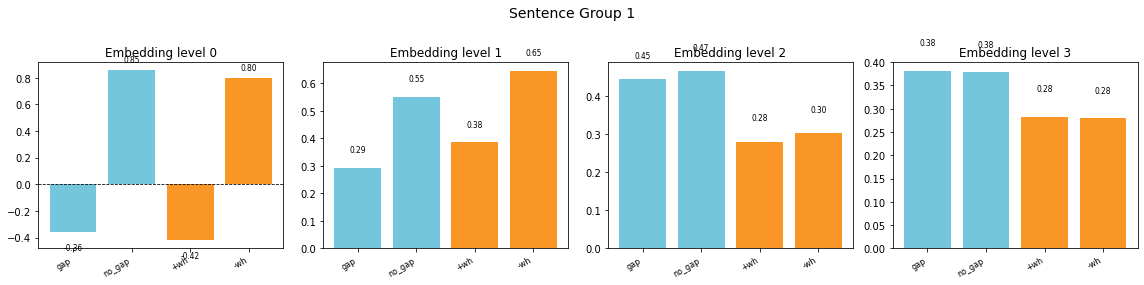

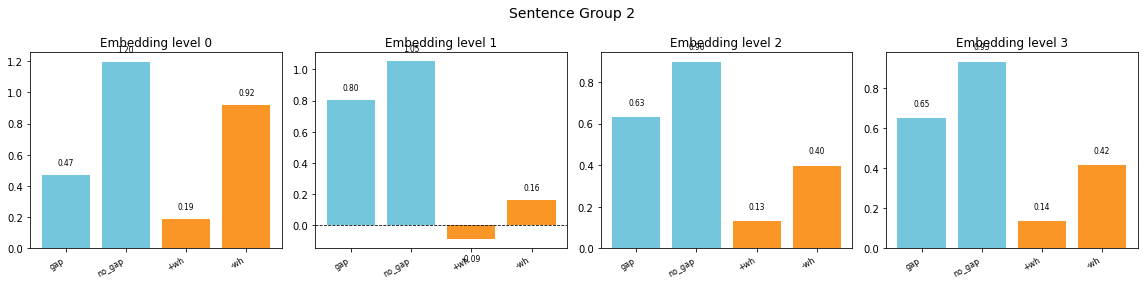

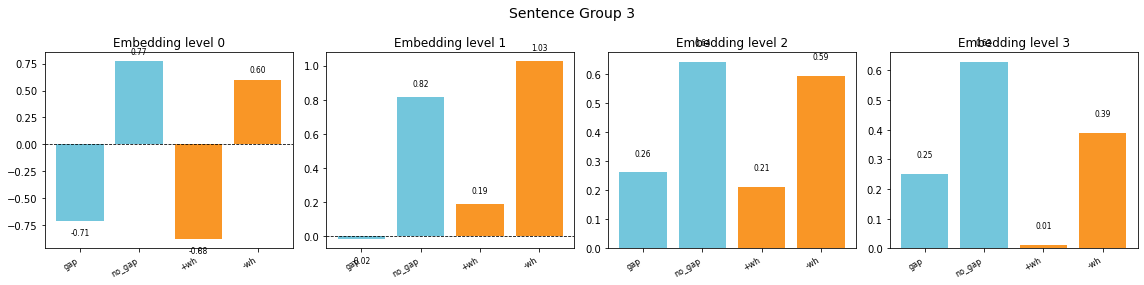

In [24]:
df = pd.read_csv("../data/model_outputs/grnn_pilot_subject_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global', gap_type='subject')